In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from scipy.stats import fisher_exact

In [3]:
path = ('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_for_figures/4_Crispr_CTRL_SHAP/ctrl_final_combined_results.csv')

In [4]:
table = pd.read_csv(path)

## Generate scatterplot for one feature with JUST CTRL SHAP

In [9]:
feature = ['PRPF8_5_binding']

In [10]:
cell_line = ['K562']

In [11]:
def one_feature_scatter(data, feature, cell_line):
    
    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    # ------------------------------------------------------------------
    # 1. Subset & significance filter
    # ------------------------------------------------------------------
    cell_line = cell_line[0]
    feature = feature[0]
    
    feature_subset = data[
        (data['cell_line'] == cell_line) &
        (data['Feature'] == feature)
    ].copy()

    sig_mask = (
        (feature_subset['dPSI'].abs() > 0) &
        (feature_subset['FDR'] <= 0.1)
    )

    # ------------------------------------------------------------------
    # 2. Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        feature_subset.loc[~sig_mask, 'CTRL_SHAP'],
        feature_subset.loc[~sig_mask, 'dPSI'],
        color='lightgrey',
        alpha=0.5,
        s=30,
        label='Nonsignificant'
    )

    ax.scatter(
        feature_subset.loc[sig_mask, 'CTRL_SHAP'],
        feature_subset.loc[sig_mask, 'dPSI'],
        color='tab:blue',
        alpha=0.5,
        s=30,
        label='Significant'
    )

    # ------------------------------------------------------------------
    # 3. Axes formatting
    # ------------------------------------------------------------------
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"Local SHAP", fontsize=18, labelpad=8)
    ax.set_ylabel(r"$\Delta\psi$", fontsize=18, labelpad=8)
    ax.tick_params(axis='both', labelsize=12)

    parts = feature.split('_')
    rbp_name = parts[0]
    position = parts[1] if len(parts) > 1 else ''
    ax.set_title(f"{rbp_name} Position {position} — {cell_line}", fontsize=22, pad=10)

    ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=18,
    markerscale=1.5
)

    plt.tight_layout()
    plt.show()

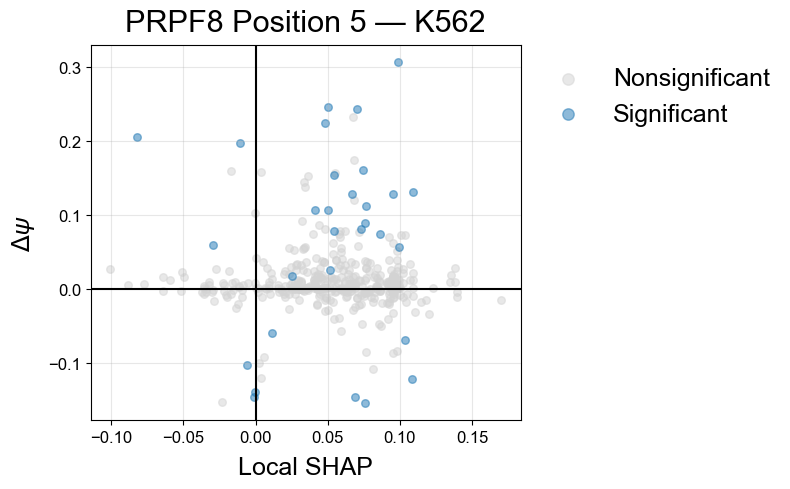

In [12]:
one_feature_scatter(table, feature, cell_line)